# 🍺 Análise de Classificadores — Dados de Cerveja

Comparação dos modelos:
- **Naive Bayes**
- **Regressão Logística**
- **Árvore de Decisão — FULL**
- **Árvore de Decisão — 2 Níveis (max_depth=2)**

## 1. Importações

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn import linear_model, tree, naive_bayes
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

## 2. Carregamento e Preparação dos Dados

In [32]:
df = pd.read_excel('dados_cerveja_nota.xlsx')

df['aprovado'] = (df['nota'] > 5).astype(int)

df

,id,cerveja,nota,aprovado
0,1,1,0.75,0
1,2,1,3.00,0
2,3,2,1.75,0
3,4,3,1.75,0
4,5,4,4.20,0
5,6,4,6.50,1
6,7,5,2.90,0
7,8,6,6.20,1
8,9,6,7.00,1
9,10,7,6.20,1


### Distribuição da variável alvo

In [33]:
df['aprovado'].value_counts().rename({0: 'Reprovado (0)', 1: 'Aprovado (1)'})

aprovado
Aprovado (1)     9
Reprovado (0)    6
Name: count, dtype: int64

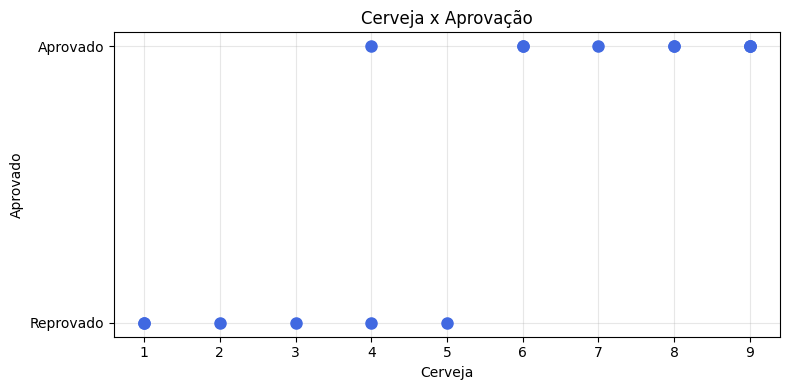

In [34]:
plt.figure(figsize=(8, 4), dpi=100)
plt.plot(df['cerveja'], df['aprovado'], 'o', color='royalblue', ms=8)
plt.grid(True, alpha=0.3)
plt.title('Cerveja x Aprovação')
plt.xlabel('Cerveja')
plt.ylabel('Aprovado')
plt.yticks([0, 1], ['Reprovado', 'Aprovado'])
plt.tight_layout()
plt.show()

## 3. Treinamento dos Modelos

In [35]:
X = df[['cerveja']]
y = df['aprovado']
X_unique = df[['cerveja']].drop_duplicates().sort_values('cerveja')

#### Naive Bayes

In [ ]:
nb = naive_bayes.GaussianNB()
nb.fit(X, y)
nb_pred = nb.predict(X)
nb_pred_u = nb.predict(X_unique)
nb_prob = nb.predict_proba(X_unique)[:, 1]

#### Regressão Logística 

In [ ]:
reg = linear_model.LogisticRegression(penalty=None, fit_intercept=True)
reg.fit(X, y)
reg_pred = reg.predict(X)
reg_pred_u = reg.predict(X_unique)
reg_prob = reg.predict_proba(X_unique)[:, 1]

#### Árvore de Decisão — FULL

In [39]:
arvore_full = tree.DecisionTreeClassifier(random_state=42)
arvore_full.fit(X, y)
af_pred = arvore_full.predict(X)
af_pred_u = arvore_full.predict(X_unique)
af_prob = arvore_full.predict_proba(X_unique)[:, 1]

#### Árvore de Decisão — max_depth=2

In [38]:
arvore_d2 = tree.DecisionTreeClassifier(random_state=42, max_depth=2)
arvore_d2.fit(X, y)
ad2_pred   = arvore_d2.predict(X)
ad2_pred_u = arvore_d2.predict(X_unique)
ad2_prob   = arvore_d2.predict_proba(X_unique)[:, 1]

## 4. Métricas de Desempenho

### 4.1 Naive Bayes

In [40]:
acc_nb = accuracy_score(y, nb_pred)
auc_nb = roc_auc_score(y, nb.predict_proba(X)[:, 1])
cm_nb  = confusion_matrix(y, nb_pred)

print(f"  Acurácia : {acc_nb:.4f}")
print(f"  AUC-ROC  : {auc_nb:.4f}")
print(f"  Matriz de Confusão:\n{cm_nb}")
print(classification_report(y, nb_pred, target_names=['Reprovado','Aprovado'], zero_division=0))

  Acurácia : 0.8667
  AUC-ROC  : 0.9722
  Matriz de Confusão:
[[5 1]
 [1 8]]
              precision    recall  f1-score   support

   Reprovado       0.83      0.83      0.83         6
    Aprovado       0.89      0.89      0.89         9

    accuracy                           0.87        15
   macro avg       0.86      0.86      0.86        15
weighted avg       0.87      0.87      0.87        15



### 4.2 Regressão Logística

In [41]:
acc_reg = accuracy_score(y, reg_pred)
auc_reg = roc_auc_score(y, reg.predict_proba(X)[:, 1])
cm_reg  = confusion_matrix(y, reg_pred)

print(f"  Acurácia : {acc_reg:.4f}")
print(f"  AUC-ROC  : {auc_reg:.4f}")
print(f"  Matriz de Confusão:\n{cm_reg}")
print(classification_report(y, reg_pred, target_names=['Reprovado','Aprovado'], zero_division=0))

  Acurácia : 0.8667
  AUC-ROC  : 0.9722
  Matriz de Confusão:
[[5 1]
 [1 8]]
              precision    recall  f1-score   support

   Reprovado       0.83      0.83      0.83         6
    Aprovado       0.89      0.89      0.89         9

    accuracy                           0.87        15
   macro avg       0.86      0.86      0.86        15
weighted avg       0.87      0.87      0.87        15



### 4.3 Árvore de Decisão — FULL

In [42]:
acc_af = accuracy_score(y, af_pred)
auc_af = roc_auc_score(y, arvore_full.predict_proba(X)[:, 1])
cm_af  = confusion_matrix(y, af_pred)

print(f"  Acurácia : {acc_af:.4f}")
print(f"  AUC-ROC  : {auc_af:.4f}")
print(f"  Matriz de Confusão:\n{cm_af}")
print(classification_report(y, af_pred, target_names=['Reprovado','Aprovado'], zero_division=0))

  Acurácia : 0.9333
  AUC-ROC  : 0.9907
  Matriz de Confusão:
[[6 0]
 [1 8]]
              precision    recall  f1-score   support

   Reprovado       0.86      1.00      0.92         6
    Aprovado       1.00      0.89      0.94         9

    accuracy                           0.93        15
   macro avg       0.93      0.94      0.93        15
weighted avg       0.94      0.93      0.93        15



### 4.4 Árvore de Decisão — D2 (max_depth=2)

In [43]:
acc_ad2 = accuracy_score(y, ad2_pred)
auc_ad2 = roc_auc_score(y, arvore_d2.predict_proba(X)[:, 1])
cm_ad2  = confusion_matrix(y, ad2_pred)

print(f"  Acurácia : {acc_ad2:.4f}")
print(f"  AUC-ROC  : {auc_ad2:.4f}")
print(f"  Matriz de Confusão:\n{cm_ad2}")
print(classification_report(y, ad2_pred, target_names=['Reprovado','Aprovado'], zero_division=0))

  Acurácia : 0.9333
  AUC-ROC  : 0.9815
  Matriz de Confusão:
[[6 0]
 [1 8]]
              precision    recall  f1-score   support

   Reprovado       0.86      1.00      0.92         6
    Aprovado       1.00      0.89      0.94         9

    accuracy                           0.93        15
   macro avg       0.93      0.94      0.93        15
weighted avg       0.94      0.93      0.93        15



### 4.5 Tabela Resumo

In [44]:
summary = [
    {'Modelo': 'Naive Bayes',         'Acurácia': f'{acc_nb:.2%}',  'AUC-ROC': f'{auc_nb:.4f}',  'TP': cm_nb[1,1],  'TN': cm_nb[0,0],  'FP': cm_nb[0,1],  'FN': cm_nb[1,0]},
    {'Modelo': 'Reg. Logística',      'Acurácia': f'{acc_reg:.2%}', 'AUC-ROC': f'{auc_reg:.4f}', 'TP': cm_reg[1,1], 'TN': cm_reg[0,0], 'FP': cm_reg[0,1], 'FN': cm_reg[1,0]},
    {'Modelo': 'Árvore Full',         'Acurácia': f'{acc_af:.2%}',  'AUC-ROC': f'{auc_af:.4f}',  'TP': cm_af[1,1],  'TN': cm_af[0,0],  'FP': cm_af[0,1],  'FN': cm_af[1,0]},
    {'Modelo': 'Árvore D2 (depth=2)', 'Acurácia': f'{acc_ad2:.2%}', 'AUC-ROC': f'{auc_ad2:.4f}', 'TP': cm_ad2[1,1], 'TN': cm_ad2[0,0], 'FP': cm_ad2[0,1], 'FN': cm_ad2[1,0]},
]

summary_df = pd.DataFrame(summary)
summary_df

,Modelo,Acurácia,AUC-ROC,TP,TN,FP,FN
0,Naive Bayes,86.67%,0.9722,8,5,1,1
1,Reg. Logística,86.67%,0.9722,8,5,1,1
2,Árvore Full,93.33%,0.9907,8,6,0,1
3,Árvore D2 (depth=2),93.33%,0.9815,8,6,0,1


## 5. Visualizações

### Setup de Cores e Valores

In [45]:
x_vals = X_unique['cerveja'].values

colors = {
    'obs':  'royalblue',
    'nb':   ('#2ecc71', '#27ae60'),
    'reg':  ('#e74c3c', '#c0392b'),
    'full': ('#f39c12', '#d35400'),
    'd2':   ('#9b59b6', '#8e44ad'),
}

### 5.1 Comparação Geral — Todos os Modelos

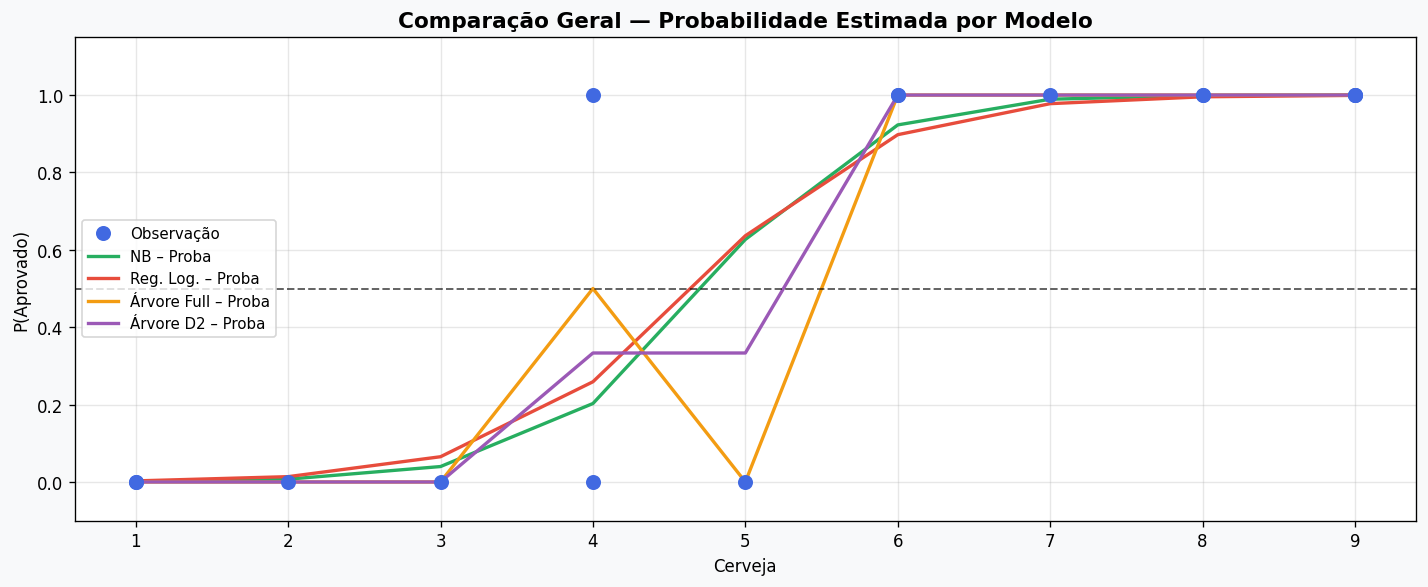

In [46]:
fig, ax0 = plt.subplots(figsize=(12, 5), dpi=120)
fig.patch.set_facecolor('#f8f9fa')
ax0.set_facecolor('#ffffff')

ax0.plot(df['cerveja'], df['aprovado'], 'o', color=colors['obs'], ms=8, zorder=5, label='Observação')
ax0.plot(x_vals, nb_prob,  '-', color=colors['nb'][1],   lw=2, label='NB – Proba')
ax0.plot(x_vals, reg_prob, '-', color=colors['reg'][0],  lw=2, label='Reg. Log. – Proba')
ax0.plot(x_vals, af_prob,  '-', color=colors['full'][0], lw=2, label='Árvore Full – Proba')
ax0.plot(x_vals, ad2_prob, '-', color=colors['d2'][0],   lw=2, label='Árvore D2 – Proba')
ax0.axhline(0.5, ls='--', color='black', lw=1.2, alpha=0.6)
ax0.set_title('Comparação Geral — Probabilidade Estimada por Modelo', fontsize=13, fontweight='bold')
ax0.set_xlabel('Cerveja'); ax0.set_ylabel('P(Aprovado)')
ax0.legend(loc='center left', fontsize=9)
ax0.grid(True, alpha=0.3)
ax0.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

### 5.2 Naive Bayes — Predição e Probabilidade

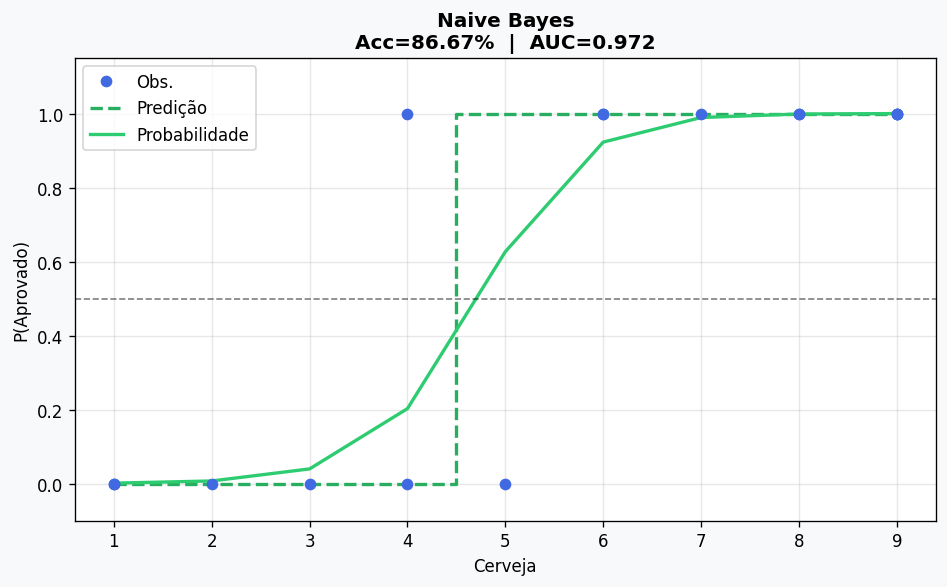

In [47]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

ax.plot(df['cerveja'], df['aprovado'], 'o', color=colors['obs'], ms=6, zorder=5, label='Obs.')
ax.step(x_vals, nb_pred_u, where='mid', color=colors['nb'][1], lw=2, ls='--', label='Predição')
ax.plot(x_vals, nb_prob, color=colors['nb'][0], lw=2, label='Probabilidade')
ax.axhline(0.5, ls='--', color='black', lw=1, alpha=0.5)
ax.set_title(f'Naive Bayes\nAcc={acc_nb:.2%}  |  AUC={auc_nb:.3f}', fontweight='bold')
ax.set_xlabel('Cerveja'); ax.set_ylabel('P(Aprovado)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

### 5.3 Regressão Logística — Predição e Probabilidade

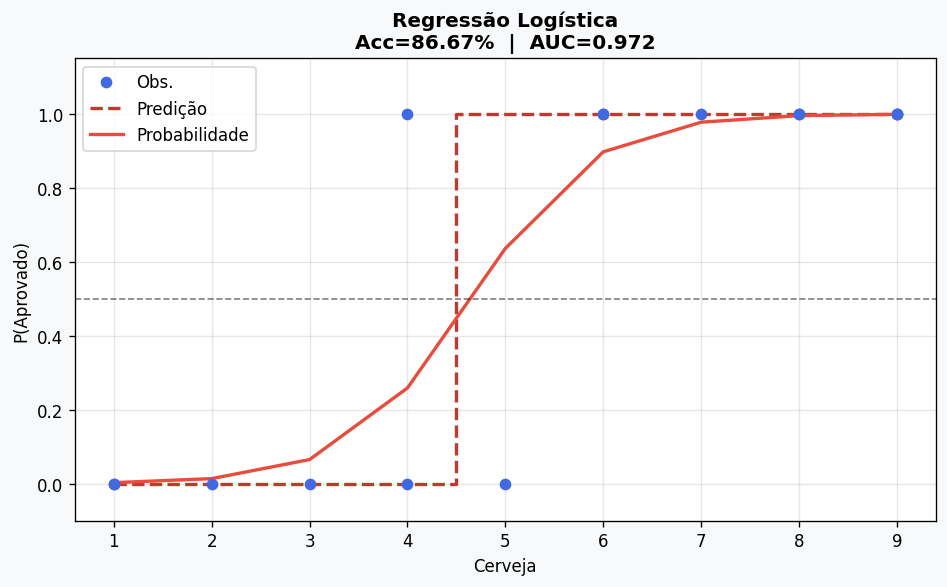

In [48]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

ax.plot(df['cerveja'], df['aprovado'], 'o', color=colors['obs'], ms=6, zorder=5, label='Obs.')
ax.step(x_vals, reg_pred_u, where='mid', color=colors['reg'][1], lw=2, ls='--', label='Predição')
ax.plot(x_vals, reg_prob, color=colors['reg'][0], lw=2, label='Probabilidade')
ax.axhline(0.5, ls='--', color='black', lw=1, alpha=0.5)
ax.set_title(f'Regressão Logística\nAcc={acc_reg:.2%}  |  AUC={auc_reg:.3f}', fontweight='bold')
ax.set_xlabel('Cerveja'); ax.set_ylabel('P(Aprovado)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

### 5.4 Árvore de Decisão — FULL — Predição e Probabilidade

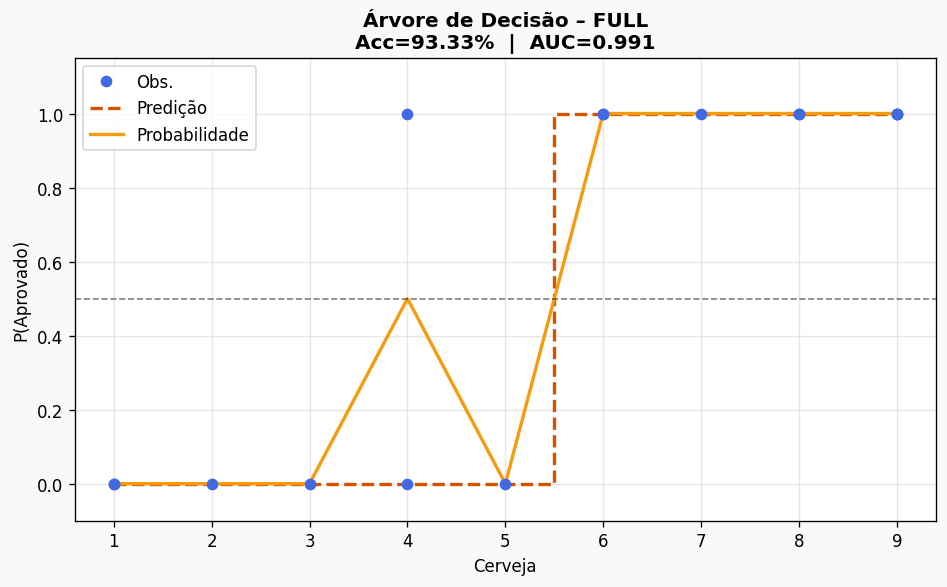

In [49]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

ax.plot(df['cerveja'], df['aprovado'], 'o', color=colors['obs'], ms=6, zorder=5, label='Obs.')
ax.step(x_vals, af_pred_u, where='mid', color=colors['full'][1], lw=2, ls='--', label='Predição')
ax.plot(x_vals, af_prob, color=colors['full'][0], lw=2, label='Probabilidade')
ax.axhline(0.5, ls='--', color='black', lw=1, alpha=0.5)
ax.set_title(f'Árvore de Decisão – FULL\nAcc={acc_af:.2%}  |  AUC={auc_af:.3f}', fontweight='bold')
ax.set_xlabel('Cerveja'); ax.set_ylabel('P(Aprovado)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

### 5.5 Árvore de Decisão — D2 (max_depth=2) — Predição e Probabilidade

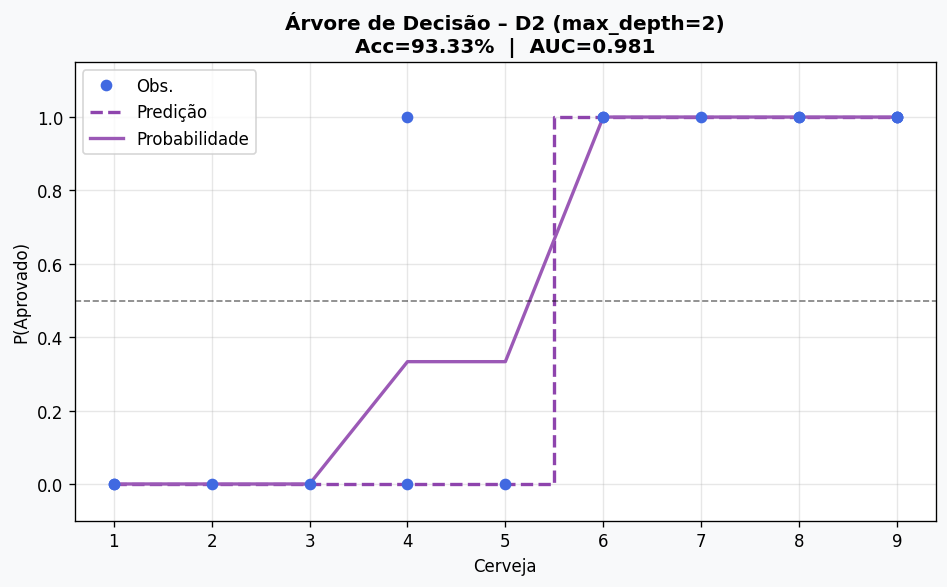

In [50]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#ffffff')

ax.plot(df['cerveja'], df['aprovado'], 'o', color=colors['obs'], ms=6, zorder=5, label='Obs.')
ax.step(x_vals, ad2_pred_u, where='mid', color=colors['d2'][1], lw=2, ls='--', label='Predição')
ax.plot(x_vals, ad2_prob, color=colors['d2'][0], lw=2, label='Probabilidade')
ax.axhline(0.5, ls='--', color='black', lw=1, alpha=0.5)
ax.set_title(f'Árvore de Decisão – D2 (max_depth=2)\nAcc={acc_ad2:.2%}  |  AUC={auc_ad2:.3f}', fontweight='bold')
ax.set_xlabel('Cerveja'); ax.set_ylabel('P(Aprovado)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 1.15)
plt.tight_layout()
plt.show()

### 5.2 Matrizes de Confusão

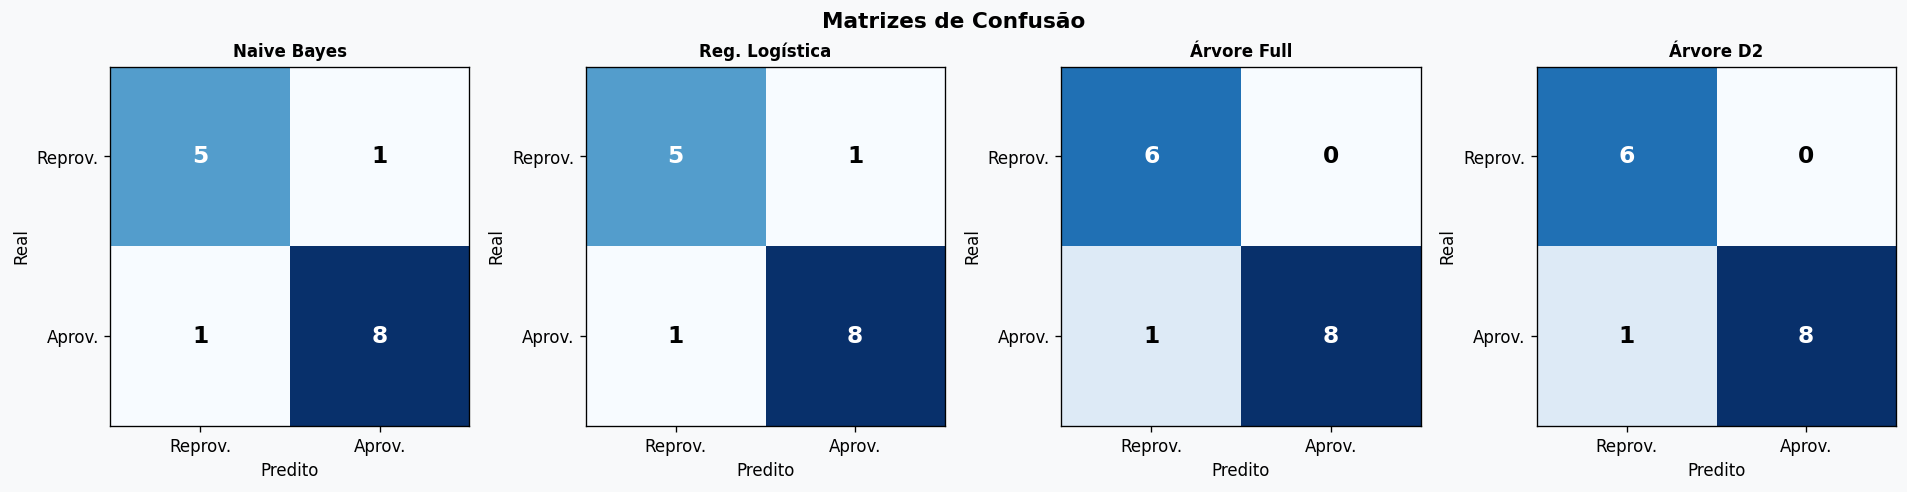

In [51]:
fig2, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=120)
fig2.patch.set_facecolor('#f8f9fa')

model_names_short = ['Naive Bayes', 'Reg. Logística', 'Árvore Full', 'Árvore D2']
preds_all = [nb_pred, reg_pred, af_pred, ad2_pred]
pal = [colors['nb'][0], colors['reg'][0], colors['full'][0], colors['d2'][0]]

for ax, name, pred, c in zip(axes, model_names_short, preds_all, pal):
    cm = confusion_matrix(y, pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Reprov.','Aprov.']); ax.set_yticklabels(['Reprov.','Aprov.'])
    ax.set_xlabel('Predito'); ax.set_ylabel('Real')
    ax.set_title(name, fontweight='bold', fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.suptitle('Matrizes de Confusão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Visualização das Árvores de Decisão

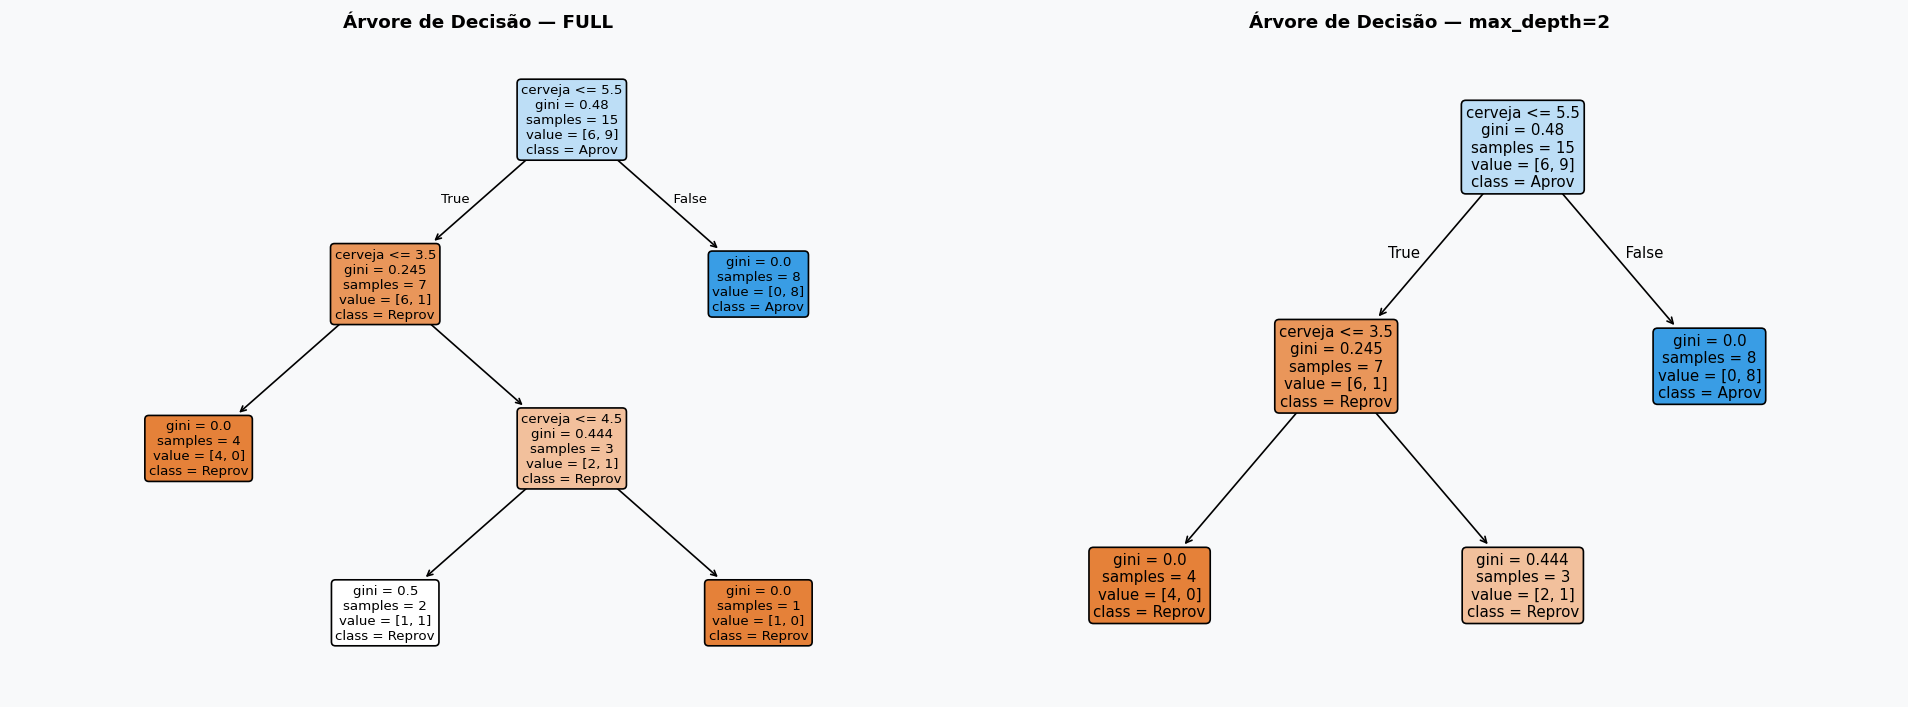

In [52]:
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
fig3.patch.set_facecolor('#f8f9fa')

tree.plot_tree(arvore_full, feature_names=['cerveja'],
               class_names=['Reprov','Aprov'], filled=True,
               rounded=True, fontsize=8, ax=ax1)
ax1.set_title('Árvore de Decisão — FULL', fontweight='bold', fontsize=11)

tree.plot_tree(arvore_d2, feature_names=['cerveja'],
               class_names=['Reprov','Aprov'], filled=True,
               rounded=True, fontsize=9, ax=ax2)
ax2.set_title('Árvore de Decisão — max_depth=2', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 6. Conclusão

| Modelo | Acurácia | AUC-ROC | FP | FN |
|---|---|---|---|---|
| Naive Bayes | 86,67% | 0,9722 | 1 | 1 |
| Regressão Logística | 86,67% | 0,9722 | 1 | 1 |
| Árvore Full | **93,33%** | **0,9907** | 0 | 1 |
| Árvore D2 (depth=2) | **93,33%** | 0,9815 | 0 | 1 |

- **Naive Bayes e Regressão Logística** apresentaram desempenho equivalente (Acc=86,67%, AUC=0,9722), errando 2 observações cada.
- **Árvore Full** obteve o maior AUC (0,9907), porém sem restrição de profundidade corre risco de *overfitting*.
- **Árvore D2** é o modelo mais equilibrado: mesma acurácia da Full (93,33%), menor complexidade e melhor capacidade de generalização.